# Multiple Linear Regression

Multiple Linear Regression is an extension of Simple Linear Regression.

Instead of using one input feature, Multiple Linear Regression uses
multiple input features to predict a continuous target.

The general equation is:

y = b0 + b1x1 + b2x2 + ... + bnxn

Where:

y  → Predicted target
b0 → Intercept
b1, b2, ..., bn → Coefficients
x1, x2, ..., xn → Input features

Example:

tip = b0 + b1(total_bill) + b2(size)

The model learns the contribution of each feature to the target.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [3]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [4]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## Features and Target

We will predict:

Target:
- tip

Features:
- total_bill
- size

Here we use two independent variables instead of one.

The model will learn:

total_bill + size → tip

In [5]:
X = df[
    [
        "total_bill",
        "size"
    ]
]

y = df["tip"]

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
   total_bill  size
0       16.99     2
1       10.34     3
2       21.01     3
3       23.68     2
4       24.59     4

y:
0    1.01
1    1.66
2    3.50
3    3.31
4    3.61
Name: tip, dtype: float64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (195, 2)
Testing: (49, 2)


In [7]:
model = LinearRegression()

In [8]:
model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.09,0.27]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['total_bill','size']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.5681
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


## Intercept

The intercept is the predicted value of the target when all input
features are zero.

In the equation:

y = b0 + b1x1 + b2x2

b0 is the intercept.

In [9]:
print("Intercept:", model.intercept_)

Intercept: 0.5681370921350046


## Coefficients

Each feature has its own coefficient.

The coefficient represents the expected change in the target when that
feature increases by one unit, while the other features remain constant.

In [10]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,total_bill,0.090881
1,size,0.265018


In [11]:
print(
    f"tip = {model.intercept_:.3f} "
    f"+ ({model.coef_[0]:.3f} × total_bill) "
    f"+ ({model.coef_[1]:.3f} × size)"
)

tip = 0.568 + (0.091 × total_bill) + (0.265 × size)


In [12]:
y_pred = model.predict(X_test)

y_pred[:10]

array([2.89943693, 1.89520002, 3.85933994, 3.9811207 , 2.27962736,
       2.72403627, 3.68283259, 2.23236915, 2.44139584, 2.49592454])

In [13]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,3.18,2.899437
1,2.00,1.895200
2,2.00,3.859340
3,5.16,3.981121
4,2.00,2.279627
5,2.00,2.724036
6,2.56,3.682833
7,2.52,2.232369
8,3.23,2.441396
9,3.00,2.495925


In [14]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 0.6639235737596481


In [15]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 0.6485996190543517


In [16]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.8053568271607013


In [17]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score:", r2)

R² Score: 0.4811084097989491


In [18]:
print("Multiple Linear Regression Performance")
print("---------------------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Multiple Linear Regression Performance
---------------------------------------
MAE : 0.6639235737596481
MSE : 0.6485996190543517
RMSE: 0.8053568271607013
R²  : 0.4811084097989491


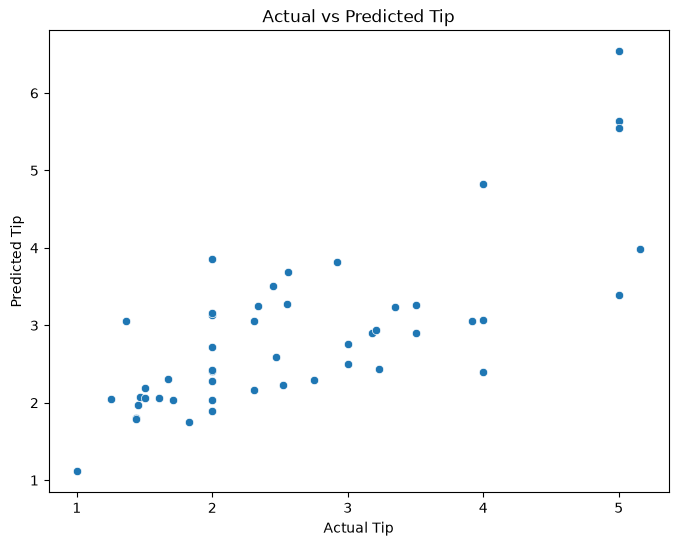

In [19]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted Tip")

plt.show()

## Residual Analysis

Residuals are the differences between actual and predicted values.

Residual:

e = y - ŷ

A residual close to zero means that the prediction is close to the
actual value.

We can visualize residuals to look for patterns.

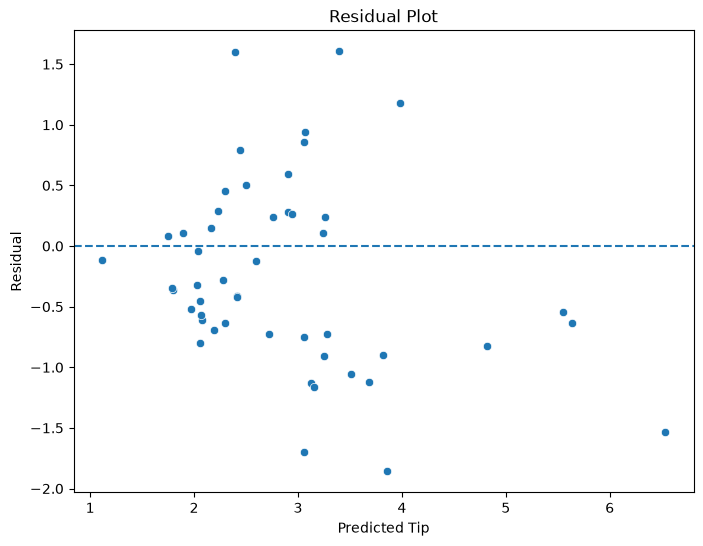

In [20]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Tip")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

## Predicting New Data

We can use the trained model to predict the tip for a new customer.

The new observation must contain the same features used during training:

- total_bill
- size

In [21]:
new_data = pd.DataFrame({
    "total_bill": [50],
    "size": [3]
})

prediction = model.predict(
    new_data
)

print("Predicted Tip:", prediction[0])

Predicted Tip: 5.907248114246907


## Why Use Multiple Features?

Simple Linear Regression:

total_bill → tip

Multiple Linear Regression:

total_bill + size → tip

Using multiple relevant features can allow the model to capture more
information about the target.

However, adding more features does not automatically make a model
better. Irrelevant or highly correlated features can hurt performance.

## Multicollinearity

Multicollinearity occurs when independent variables are strongly
correlated with each other.

For example:

Feature 1 ↔ Feature 2

If two features contain very similar information, it can become
difficult to interpret their individual coefficients.

Multicollinearity is especially important when interpreting the
coefficients of Multiple Linear Regression.

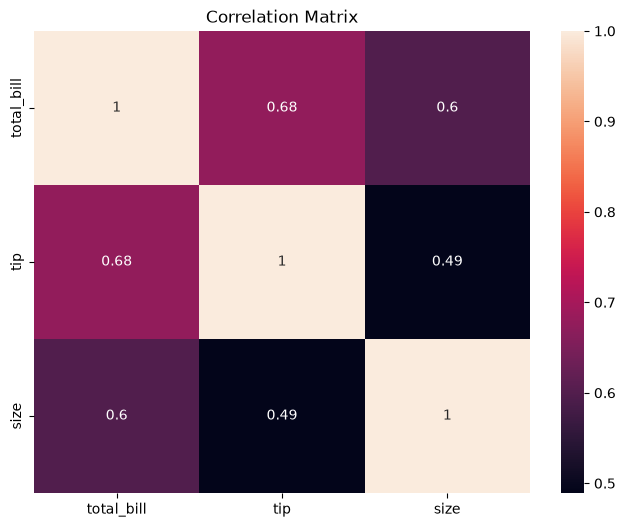

In [22]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[
        [
            "total_bill",
            "tip",
            "size"
        ]
    ].corr(),
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

## Simple vs Multiple Linear Regression

### Simple Linear Regression

Uses one independent variable.

y = b0 + b1x1

Example:

total_bill → tip


### Multiple Linear Regression

Uses two or more independent variables.

y = b0 + b1x1 + b2x2 + ... + bnxn

Example:

total_bill + size → tip